---
title: "Climate DT Parameter - Data Access using DEDL HDA"
subtitle: "This notebook authenticates with the DestinE API, queries ECMWF Climate Digital Twin adaptation data, downloads the selected data using a  retry mechanism, and visualizes it using EarthKit."
author: "Michael Schick (EUMETSAT), Serena Avolio (EUMETSAT/Starion)"
tags: [HDA, ECMWF, Authentication, Digital Twin]
thumbnail: ../../img/ECMWF.png
license: MIT
copyright: "© 2025 EUMETSAT"
---
<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/HDA/DestinE_Digital_Twins/DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b><ul>
   <li>To search and access DEDL data a <a href="https://platform.destine.eu/"> DestinE user account</a> is needed</li>
   <li>To search and access DT data an <a href="https://platform.destine.eu/support-pages/access-policy/"> upgraded access</a> is needed.</li></ul>
<b> References: </b><ul>
    <li><a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Use-of-Harmonized-Data-Access/Use-of-Harmonized-Data-Access.html">DestinE Data Lake (DEDL) Harmonized Data Access (HDA) documentation</a> </li>
    <li> <a href="https://destine.ecmwf.int/climate-change-adaptation-digital-twin-climate-dt/">Climate Change Adaptation DT (Climate DT)</a></li>
    <li> <a href="https://confluence.ecmwf.int/display/DDCZ/Climate+DT+Phase+1+data+catalogue">Climate DT data catalogue</a></li>
    <li> <a href="https://confluence.ecmwf.int/display/DDCZ/DestinE+ClimateDT+Parameters">Climate DT Phase I Parameters</a></li>
    <li> <a href="https://confluence.ecmwf.int/display/DDCZ/DestinE+ClimateDT+Phase+2+Parameters">Climate DT Phase II Parameters</a></li></ul>
<b> Credit: </b><ul>
    <li> Earthkit and Polytope (used from HDA) are both packages provided by the European Centre for Medium-Range Weather Forecasts (ECMWF).</li></ul>
</div>


# Climate DT Parameter - Data Access using DEDL HDA
- **Objective:** This notebook has the aim to show how to use the **HDA (Harmonized Data Access) API to query and access Climate DT data parameters** and plot vector data.
    Below the main steps covered by this tutorial.
    1. [Setup](#DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb-Setup): Import the required libraries.
    1. [Search](#DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb-Search): Search for U and V component of wind. 
    2. [Order and Download](#DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb-Order-and-Download): How to filter and download Climate DT data.
    3. [Plot](#DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb-EarthKit): How to visualize hourly data on single levels data through Earthkit.

  
       
- **Data Sources:** https://destine.ecmwf.int/climate-change-adaptation-digital-twin-climate-dt/
- **Methods:** The data request is performed using HDA REST API. The variables used in this notebook are the "U component of wind" and "V component of wind". The downloaded data provides global coverage. The plot is over the Gulf of Lion, a region frequently affected by Mistral and Tramontane wind events The selected date, 11 January 2025, provides a representative example of these events and highlights the characteristic wind patterns and intensity over the region.
- **Prerequisites:** 
   - To search and access DEDL data a <a href="https://platform.destine.eu/"> DestinE user account</a> is needed
   - To search and access DT data an <a href="https://platform.destine.eu/support-pages/access-policy/"> upgraded access</a> is needed.
- **Expected Output:**
    - 1 grib file containing the requested data,
    - 2 map plot of the winds intensity, a wind arrows and speed plot and a streamlines plot.


(DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb-Setup)=
# Setup

In [1]:
pip install --user --quiet --upgrade destinelab

Note: you may need to restart the kernel to use updated packages.


Import all the required packages.

In [2]:
import destinelab as deauth
import json
import importlib.metadata

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import os
from getpass import getpass
from tqdm import tqdm
import time
from datetime import datetime
from urllib.parse import unquote
from IPython.display import JSON
import ipywidgets as w

(DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE-Series.ipynb-Search-for-U-and-V-component-of-wind)=
# Search for U and V component of wind

## Obtain Authentication Token

To search and access data we need to be authenticated. 

Below how to request of an authentication token using the destinelab package.

In [3]:
DESP_USERNAME = input("Please input your DESP username: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

Please input your DESP username:  eum-dedl-user
Please input your DESP password:  ········


DEDL/DESP Access Token Obtained Successfully


Response code: 200
DEDL/DESP Access Token Obtained Successfully


### Check if DT access is granted

If DT access is not granted, you will not be able to execute the rest of the notebook.

In [4]:
auth.is_DTaccess_allowed(access_token)

True

## HDA Endpoints
HDA API is based on the Spatio Temporal Asset Catalog specification (STAC).
When accessing DestinE data through the HDA API, it is useful to define a small set of configuration constants upfront. These typically include:

- The STAC API endpoint exposed by HDA
- The collection name

While the collection name can be specified as a constant, it does not need to be known in advance, as available collections can be discovered dynamically using the discovery API. 


In [5]:
COLLECTION_ID="EO.ECMWF.DAT.D1.DT_CLIMATE.G2.PROJECTIONS_SSP3-7.0_IFS-NEMO.R1"

In [6]:
HDA_STAC_ENDPOINT="https://hda.data.destination-earth.eu/stac/v2"
print("STAC endpoint: ", HDA_STAC_ENDPOINT)

STAC endpoint:  https://hda.data.destination-earth.eu/stac/v2


In [7]:
HDA_DISCOVERY_ENDPOINT = HDA_STAC_ENDPOINT+'/collections'
print("HDA discovery endpoint: ", HDA_DISCOVERY_ENDPOINT)

HDA discovery endpoint:  https://hda.data.destination-earth.eu/stac/v2/collections


### HDA Discovery

In this example, we aim to access the latest generation of Climate DT simulations for future projections generated by the IFS-NEMO model.

To identify the appropriate collection ID for querying the HDA, we can leverage the free-text search capability of the HDA Discovery API. For instance, you can search using keywords such as “Climate Change Adaptation Digital Twin”, “Future Projection”, and “IFS-NEMO” and “Generation-2”.

The search results will provide the relevant collection ID, along with additional useful metadata such as the temporal coverage and the available parameters.

In [8]:

discovery_json = requests.get(HDA_DISCOVERY_ENDPOINT,params = 
                             {"q": '"Climate Change Adaptation Digital Twin" AND "Future Projection" AND Generation-2 AND IFS-NEMO'}).json()

print("\nThe discovery result give us:\nthe collection ID : ", json.dumps(discovery_json["collections"][0].get("id")))
print("\nIts time extension : ", json.dumps(discovery_json["collections"][0].get("extent").get("temporal").get("interval")))



The discovery result give us:
the collection ID :  "EO.ECMWF.DAT.D1.DT_CLIMATE.G2.PROJECTIONS_SSP3-7.0_IFS-NEMO.R1"

Its time extension :  [["2015-01-01T00:00:00Z", "2049-12-31T23:59:59Z"]]


In the following cell, we use the output of the discovery request to explore the contents of the selected Climate DT simulation. 

The cell-s output displays all variables (parameters) available within the collection and provides a search interface for browsing them. By selecting a specific variable, users can examine its metadata and better understand its meaning, units, and intended use. This information can then be used to define the parameters to be included in subsequent HDA data requests.

In [9]:
# print("\nThe available parameters: ")
print("(Type in the text box to narrow the list. When only one item remains, its details will appear)")

parameters=discovery_json["collections"][0]["cube:variables"]
keys = sorted(parameters)
txt = w.Text(description="")
out = w.Output()
def run(_):
    q = txt.value.lower()
    with out:
        out.clear_output(); 
        matches = [k for k in keys if q in k.lower()]
        for k in matches:
            print(k)
            if len(matches)==1:            
                var = discovery_json["collections"][0]["cube:variables"][k]
                print(var["description"], "\n")
                print(json.dumps(var["attrs"], indent=2))
                #print(json.dumps(discovery_json["collections"][0]["cube:variables"][k], indent=2))

                
txt.observe(run, names="value"); display(txt, out); run(None)

#print("\nThe information related to each parameter, e.g. the 2 metre temperature: ")
#JSON(discovery_json["collections"][0].get("cube:variables").get("2_metre_temperature(sfc)"))

(Type in the text box to narrow the list. When only one item remains, its details will appear)


Text(value='')

Output()

From the list of available parameters, we select **U_component_of_wind and V_component_of_wind** at the pressure level (levtype = pl). 

Using the metadata, we can extract the information required to formulate the HDA query and retrieve the desired product.

In [10]:
components_of_wind=[]
for var_name, var_info in parameters.items():
    if var_name.endswith("component_of_wind(clte_pl)"):
        var_type = var_info.get("type")
        var_unit = var_info.get("unit")
        var_url = var_info.get("attrs").get("url")

        components_of_wind.append ( {
            "type": var_type,
            "unit": var_unit,
            "long_name": var_info.get("attrs").get("long_name"),
            "shortName": var_info.get("attrs").get("shortName"),
            "standard_name": var_info.get("attrs").get("standard_name"),
            "stream": var_info.get("attrs").get("stream"),
            "url": var_url,
            "parameter_ID": var_info.get("attrs").get("parameter_ID"),
            "product_type": var_info.get("attrs").get("product_type"),
            "levtype": var_info.get("attrs").get("levtype"),
            "levelist": var_info.get("attrs").get("levelist"),
            "time": var_info.get("attrs").get("time")
        })
components_of_wind

[{'type': 'data',
  'unit': 'm s-1',
  'long_name': 'U component of wind',
  'shortName': 'u',
  'standard_name': 'U_component_of_wind',
  'stream': 'clte',
  'url': 'https://codes.ecmwf.int/grib/param-db/131',
  'parameter_ID': '131',
  'product_type': 'forecast',
  'levtype': 'pl',
  'levelist': '1000,925,850,700,600,500,400,300,250,200,150,100,70,50,30,20,10,5,1',
  'time': 'Hourly'},
 {'type': 'data',
  'unit': 'm s-1',
  'long_name': 'V component of wind',
  'shortName': 'v',
  'standard_name': 'V_component_of_wind',
  'stream': 'clte',
  'url': 'https://codes.ecmwf.int/grib/param-db/132',
  'parameter_ID': '132',
  'product_type': 'forecast',
  'levtype': 'pl',
  'levelist': '1000,925,850,700,600,500,400,300,250,200,150,100,70,50,30,20,10,5,1',
  'time': 'Hourly'}]

In [11]:
response = requests.post(HDA_STAC_ENDPOINT+"/search", headers=auth_headers, json={
 "collections": [COLLECTION_ID],
    "datetime": "2025-01-11T00:00:00Z",
    "query":  {
    "ecmwf:resolution":{"eq": "high"},
    "ecmwf:stream":{"eq": components_of_wind[0]["stream"]}, 
    "ecmwf:levtype":{"eq": components_of_wind[0]["levtype"]},         
    "ecmwf:levelist": {"eq":  ["1000"]},      # 1000 hPa ~100 m (near sea level)],
    "ecmwf:time":{"eq": ["1200"]},
    "ecmwf:param":{"eq": [components_of_wind[0]["parameter_ID"],components_of_wind[1]["parameter_ID"]]}
    }
})

In [ ]:
if(response.status_code!= 200):
    (print(response.text))
response.raise_for_status()

product = response.json()["features"][0]
JSON(product)

(DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb-Order-and-Download)=
# Order and Download


Selecting the correct collection and set up the filter to request the data of interest, from the previous search result we can retrieve the precise body and URL needed to *order* and *download* the data

Below we retrieve the precise body and URL to access the data. 

In [13]:
link = next((l for l in product.get('links', []) if l.get("rel") == "retrieve"), None)

if link:
    href = link.get("href")
    body = link.get("body")   # optional: depends on extension
    print("order endpoint:", href)
    print("order body, same as the polytope format:")
    print(json.dumps(body, indent=4))
else:
    print(f"No link with rel='{target_rel}' found")


order endpoint: https://hda.data.destination-earth.eu/stac/v2/collections/EO.ECMWF.DAT.D1.DT_CLIMATE.G2.PROJECTIONS_SSP3-7.0_IFS-NEMO.R1/order
order body, same as the polytope format:
{
    "activity": "projections",
    "class": "d1",
    "dataset": "climate-dt",
    "date": "20250111/to/20250111",
    "experiment": "SSP3-7.0",
    "expver": "0001",
    "generation": "2",
    "levelist": [
        "1000"
    ],
    "levtype": "pl",
    "model": "IFS-NEMO",
    "param": [
        "131",
        "132"
    ],
    "realization": "1",
    "resolution": "high",
    "stream": "clte",
    "time": [
        "1200"
    ],
    "type": "fc"
}


We can now proceed placing the data order using the order endpoint. 

The ordering workflow consists of the following steps:
- **STEP1 - submit an order** with parameters directly to the collection,
- **STEP2 - monitor** the returned STAC item status,
- **STEP3 - download** the asset when ready.

## STEP 1 - Submit an Order

We use the defined filter to submit the order

In [14]:
#Sometimes requests to polytope get timeouts, it is then convenient define a retry strategy
retry_strategy = Retry(
    total=10,  # Total number of retries
    status_forcelist=[500, 502, 503, 504],  # List of 5xx status codes to retry on
    allowed_methods=["GET",'POST'],  # Methods to retry
    backoff_factor=1  # Wait time between retries (exponential backoff)
)

# Create an adapter with the retry strategy
adapter = HTTPAdapter(max_retries=retry_strategy)

# Create a session and mount the adapter
session = requests.Session()
session.mount("https://", adapter)


response = session.post(href, json=body, headers=auth_headers)

if response.status_code != 200:
    print(response.content)
response.raise_for_status()
    
ordered_item = response.json()
    
product_id = ordered_item["id"]
storage_tier = ordered_item["properties"].get("storage:tier", "online")
order_status = ordered_item["properties"].get("order:status", "unknown")
federation_backend = ordered_item["properties"].get("federation:backends", [None])[0]
    
print(f"Product ordered: {product_id}")
print(f"Provider: {federation_backend}")
print(f"Order status: {order_status}")    

self_url = f"{HDA_STAC_ENDPOINT}/collections/{COLLECTION_ID}/items/{product_id}"
item = {}



Product ordered: 01f3z8k982yfk34003yb8kkd3f
Provider: dedt_mn5
Order status: succeeded


## STEP 2 - Monitor the status

The status of an order can be:
- shipping, that means that the order is in progress;
- succeeded, that means that the order is completed;
- failed, that means that the order is in error.

In [15]:
#timeout and step for polling (sec)
TIMEOUT = 300
STEP = 1
ONLINE_STATUS = "online"
ORDER_STATUS = "succeeded"

for i in range(0, TIMEOUT, STEP):
    print(f"Polling {i + 1}/{TIMEOUT // STEP}")
    
    response = session.get(self_url, headers=auth_headers)
    if response.status_code != 200:
        print(response.content)
    response.raise_for_status()
    item = response.json()
    
    print(item["properties"].get("order:status"))
    status = item["properties"].get("order:status")

    if status == ORDER_STATUS:
        download_url = item["assets"]["downloadLink"]["href"]
        print("Product is ready to be downloaded.")
        print(f"Asset URL: {download_url}")
        break
    
    time.sleep(STEP)
else:
    order_status = item["properties"].get("order:status", "unknown")
    print(f"We could not download the product after {TIMEOUT // STEP} tries. Current order status is {order_status}")



Polling 1/300
succeeded
Product is ready to be downloaded.
Asset URL: https://hda-download.marenostrum.data.destination-earth.eu/data/dedt_mn5/EO.ECMWF.DAT.D1.DT_CLIMATE.G2.PROJECTIONS_SSP3-7.0_IFS-NEMO.R1/01f3z8k982yfk34003yb8kkd3f/downloadLink


## STEP 3 - Download

In [16]:
response = session.get(download_url, stream=True, headers=auth_headers)
response.raise_for_status()
    
content_disposition = response.headers.get('Content-Disposition')
total_size = int(response.headers.get("content-length", 0))
if content_disposition:
    filename = content_disposition.split('filename=')[1].split('"')[1]
else:
    filename = os.path.basename(url)
        
# Open a local file in binary write mode and write the content
print(f"downloading {filename}")
    
with tqdm(total=total_size, unit="B", unit_scale=True) as progress_bar:
    with open(filename, 'wb') as f:
        for data in response.iter_content(1024):
            progress_bar.update(len(data))
            f.write(data)

downloading 01f3z8k982yfk34003yb8kkd3f.grib


58.5MB [00:01, 40.0MB/s]


(DEDL-HDA-EO.ECMWF.DAT.DT_CLIMATE.ipynb--EarthKit)
# EarthKit

## Loading and inspecting data

In [17]:
import earthkit.data as ekd
ds = ekd.from_source("file", filename)
ds.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
0,ecmf,u,isobaricInhPa,1000,20250111,1200,0,fc,None,healpix
1,ecmf,v,isobaricInhPa,1000,20250111,1200,0,fc,None,healpix


## Plot

The downloaded data provides global coverage; however, for the plot we focus on the **Gulf of Lion**, a region frequently affected by Mistral and Tramontane wind events. 

The Mistral is a strong northwesterly wind that accelerates through the Rhône Valley and extends over the northwestern Mediterranean, often reaching wind speeds of 25-30 m s⁻¹ (90-100 km h⁻¹) and persisting for several days. 
The selected date, 11 January 2025, provides a representative example of these conditions and highlights the characteristic wind patterns and intensity over the region.

### Wind arrows and speed

f6cf150a0f07601372b4cf8dda1b2492a07b4f0fb2126c6ed975d05ee05c74f0.npz:   0%|          | 0.00/1.15M [00:00<?, ?B…

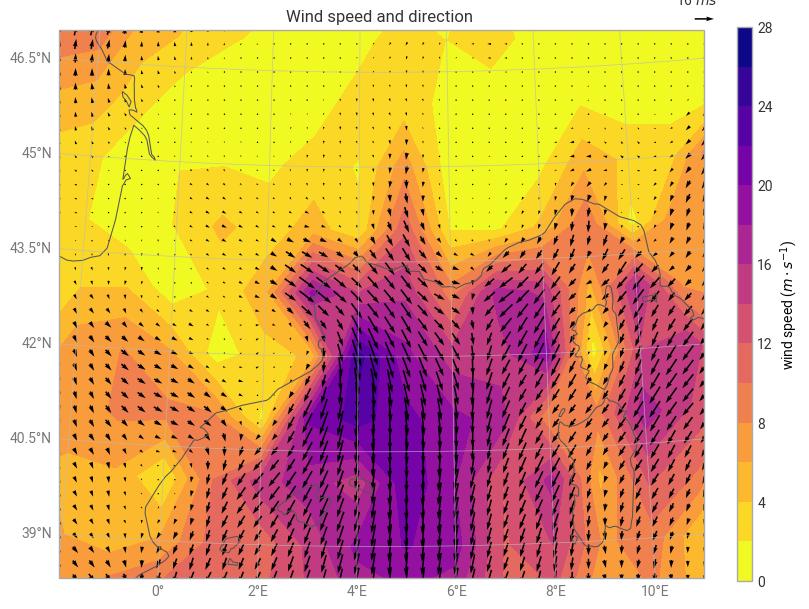

In [18]:
import earthkit.plots
chart = earthkit.plots.Map(domain=[-2,11, 38.5,47 ])
import numpy as np
from earthkit.regrid import interpolate

# the target grid is a global 1x1 degree regular latitude-longitude grid
out_grid = {"grid": [1,1]}

# perform interpolation for each field and add results to a new fieldlist stored in memory
r = interpolate(ds, out_grid=out_grid, method="linear")
chart.land()
chart.coastlines()
chart.gridlines()
chart.title("Wind speed and direction ")

style = earthkit.plots.styles.Style(
    colors="plasma_r",
    levels=range(0, 30, 2),
    units="m s-1",
)

# Convert GRIB → xarray DataArray
u = r.sel(shortName="u").to_xarray()["u"]
v = r.sel(shortName="v").to_xarray()["v"]

# Compute wind speed
speed = np.hypot(u, v)
speed.name = "wind_speed"

# ---- coloured background ----
chart.quickplot(speed, style=style)

chart.quiver(r)
chart.legend(label="wind speed ({units})", location="right")
chart.show()

### plot streamlines

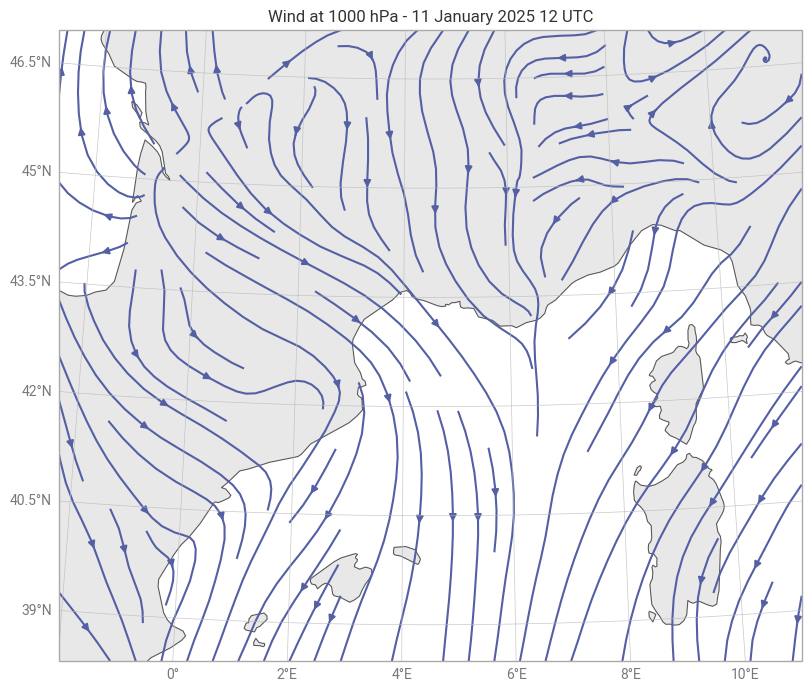

In [19]:
chart = earthkit.plots.Map(domain=[-2,11, 38.5,47 ])
chart.streamplot(r)

chart.land()
chart.coastlines()
chart.gridlines()

chart.title("{variable_name} at {level} hPa - {time:%-d %B %Y %H UTC}")

chart.show()